In [18]:
# Name: Chiiradeep R
# Reg no: 212224240028
import torch
import torch.nn as nn
import torch.nn.functional as F

In [19]:
class Model(nn.Module):
    
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3): # How many Layers?

        # Input Layers (4 futures) ---> h1 N--> N---> output (3 class)
        
        super().__init__()
        self.fc1 = nn.Linear(in_features,h1)    # input layer
        self.fc2 = nn.Linear(h1, h2)            # hidden layer
        self.out = nn.Linear(h2, out_features)  # output layer
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [20]:
# Instantiate the Model class using parameter defaults:
torch.manual_seed(32)
model = Model()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
df = pd.read_csv('iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [23]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0
149,5.9,3.0,5.1,1.8,2.0


In [24]:
X = df.drop('target',axis=1)
y = df['target']

In [25]:
type(X)

pandas.core.frame.DataFrame

In [26]:
X = X.values
y = y.values

In [27]:
type(X)

numpy.ndarray

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=33)

In [30]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [31]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [32]:
criterion = nn.CrossEntropyLoss()  # multi class clasification problem 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   # 0.000001

In [33]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [34]:
epochs = 100
losses = []

for i in range(epochs):
    
    i+=1

    # Forward and get a prediction 
    
    y_pred = model.forward(X_train)

    #Calculation Loss/error
    loss = criterion(y_pred, y_train)
    
    losses.append(loss.item())
    
    # a neat trick to save screen space:
    if i%10 == 1:
        print(f'epoch: {i}  loss: {loss.item()}')

    #Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch: 1  loss: 1.1507114171981812
epoch: 11  loss: 0.9377314448356628
epoch: 21  loss: 0.779825747013092
epoch: 31  loss: 0.6099399924278259
epoch: 41  loss: 0.40079933404922485
epoch: 51  loss: 0.25436317920684814
epoch: 61  loss: 0.15053051710128784
epoch: 71  loss: 0.10086944699287415
epoch: 81  loss: 0.08128312975168228
epoch: 91  loss: 0.07231426984071732


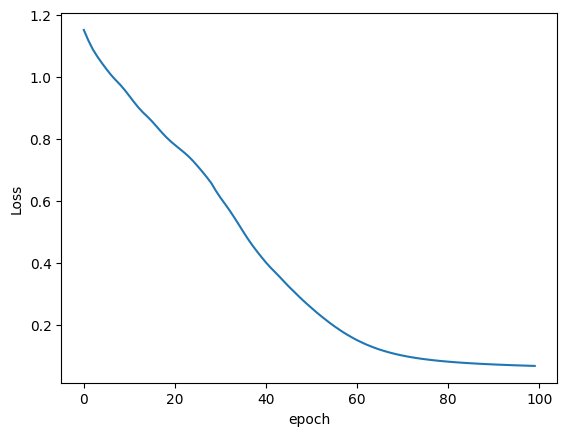

In [35]:
plt.plot(range(epochs), losses)
plt.ylabel('Loss')
plt.xlabel('epoch');


In [37]:
correct = 0

with torch.no_grad():

    for i,data in enumerate(X_test):

        y_val =model.forward(data)

        #1.) 2.) 3.)

        print(f'{i+1}.) {str(y_val)} {y_test[i]}')

        # 0 1 2

        if y_val.argmax().item() == y_test[i]:
            correct +=1

print(f'We got {correct} correct!')

1.) tensor([-2.1252,  4.8064, -0.8628]) 1
2.) tensor([-1.7985,  5.3098, -1.5449]) 1
3.) tensor([  6.3542,   0.8438, -10.0541]) 0
4.) tensor([-3.9123,  4.5958,  1.1693]) 1
5.) tensor([-7.4713,  3.2021,  5.7853]) 2
6.) tensor([-10.4976,   1.6459,   9.6297]) 2
7.) tensor([  6.3201,   0.9917, -10.1532]) 0
8.) tensor([  7.0468,   0.7059, -10.9137]) 0
9.) tensor([-7.2061,  3.3477,  5.3565]) 2
10.) tensor([-9.3960,  2.5759,  8.1033]) 2
11.) tensor([-9.8808,  2.3475,  8.7141]) 2
12.) tensor([ 6.2748,  0.6655, -9.7613]) 0
13.) tensor([-9.3142,  2.1880,  8.1947]) 2
14.) tensor([-3.7803,  4.5050,  1.0752]) 1
15.) tensor([-7.8657,  3.0117,  6.2303]) 2
16.) tensor([-1.8867,  5.1572, -1.3345]) 1
17.) tensor([-5.7006,  3.5030,  3.6696]) 2
18.) tensor([  7.1789,   0.7369, -11.1350]) 0
19.) tensor([-3.2944,  4.7931,  0.3475]) 1
20.) tensor([-7.7665,  3.7629,  5.7095]) 2
21.) tensor([  6.6499,   0.7889, -10.4252]) 0
22.) tensor([  7.4357,   0.8918, -11.6600]) 0
23.) tensor([-9.7584,  2.1744,  8.6654]) 2

In [38]:
 print(f'{i+1}.) {str(y_val.argmax().item())} {y_test[i]}')

30.) 2 2


In [39]:
torch.save(model.state_dict(),'my_iris_model.pt')

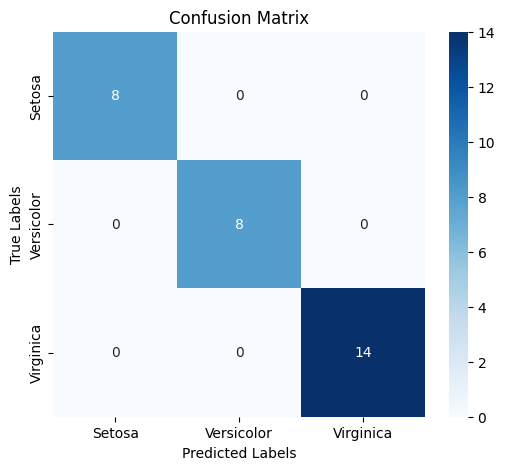

In [42]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

predictions = predicted.cpu().numpy()
actuals = y_test.cpu().numpy()

conf_matrix = confusion_matrix(actuals, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.show()